In [5]:
pip install transformers

In [6]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(0)
if torch.backends.mps.is_available():
    device=torch.device("mps")
else:
    device=torch.device("cpu")
print(device)

cpu


In [7]:
processor=ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit_model=ViTForImageClassification.from_pretrained("google/vit-base-patch16-224",output_attentions=True)
vit_model=vit_model.to(device)
vit_model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [8]:
from PIL import Image

image=Image.open("test image.webp").convert("RGB")
inputs=processor(images=image,return_tensors="pt").to(device)
with torch.no_grad():
    outputs=vit_model(**inputs)
probabilities=torch.softmax(outputs.logits,dim=-1)
top5_probabilities,top5_indices=torch.topk(probabilities,5)
for i in range(0,5):
    index=top5_indices[0][i].item()
    probability=top5_probabilities[0][i].item()
    label=vit_model.config.id2label[index]
    print(label,probability)

racer, race car, racing car 0.7859059572219849
sports car, sport car 0.18162822723388672
car wheel 0.012936808168888092
passenger car, coach, carriage 0.006186243612319231
go-kart 0.002056986093521118


In [9]:
last_layer_attention=outputs.attentions[-1]
attention=last_layer_attention[0].mean(dim=0) #197
cls_attention=attention[0,1:]
attention_grid=cls_attention.reshape(14,14).cpu().numpy()

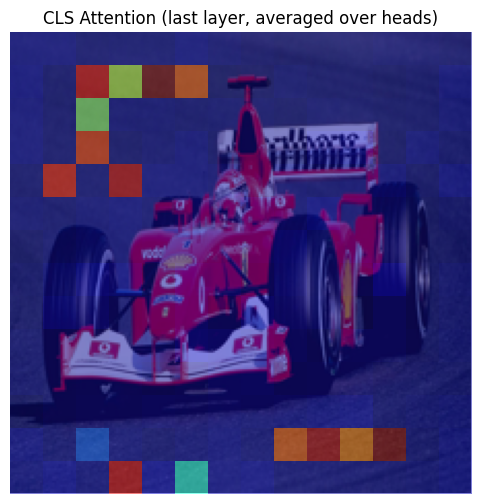

In [10]:
plt.figure(figsize=(6,6))
plt.imshow(image.resize((224,224)))
plt.imshow(attention_grid,cmap="jet",alpha=0.5,extent=(0,224,224,0))
plt.title("CLS Attention (last layer, averaged over heads)")
plt.axis("off")
plt.savefig("attention_overlay.png",bbox_inches="tight")
plt.show()

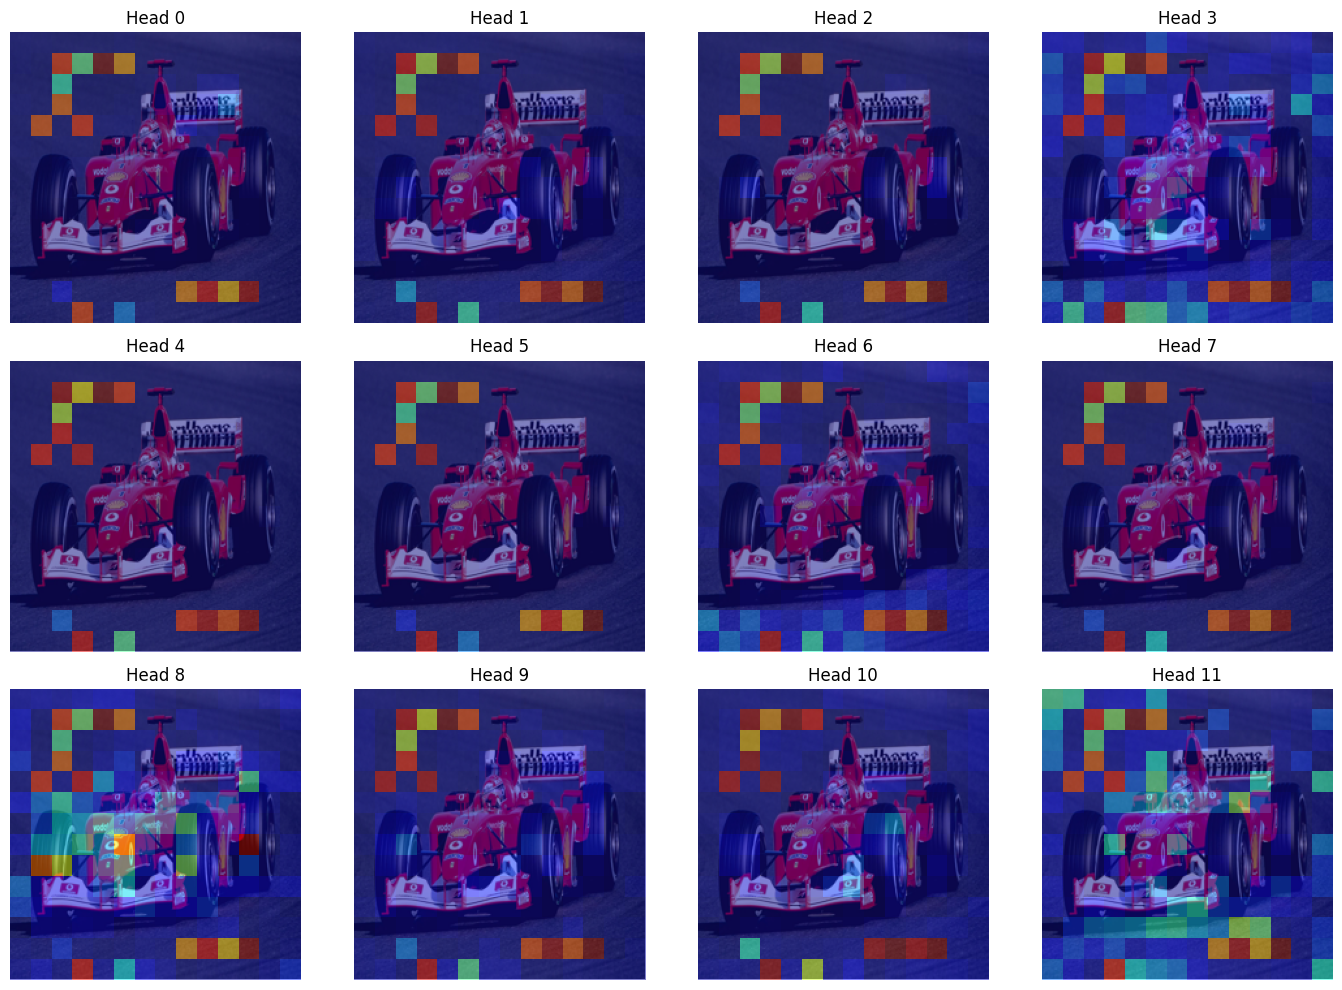

In [11]:
last_layer=outputs.attentions[-1]
num_heads=last_layer.shape[1]

fig,axes=plt.subplots(3,4,figsize=(14,10))
for head in range(num_heads):
    head_attention=last_layer[0,head]
    cls_to_patches=head_attention[0,1:]
    grid=cls_to_patches.reshape(14,14).cpu().numpy()
    row=head//4
    column=head%4
    axes[row][column].imshow(image.resize((224,224)))
    axes[row][column].imshow(grid,cmap="jet",alpha=0.5,extent=(0,224,224,0))
    axes[row][column].set_title("Head "+str(head))
    axes[row][column].axis("off")

plt.tight_layout()
plt.savefig("attention_heads.png",bbox_inches="tight")
plt.show()

In [12]:
original_index=torch.softmax(outputs.logits,-1).argmax(-1).item()

def masked_confidence_of_original(image,mask_ratio,mask_type):
    inputs=processor(images=image,return_tensors="pt").to(device)
    pixel_values=inputs["pixel_values"].clone()
    patch_size=16
    grid_size=14
    total_patches=grid_size*grid_size
    num_to_mask=int(mask_ratio*total_patches)

    if mask_type=="random":
        chosen=torch.randperm(total_patches)[:num_to_mask].tolist()
    else:
        chosen=[]
        center=grid_size//2
        offset=int((num_to_mask**0.5)//2)
        for r in range(center-offset,center+offset+1):
            for c in range(center-offset,center+offset+1):
                chosen.append(r*grid_size+c)

    for idx in chosen:
        row=(idx//grid_size)*patch_size
        col=(idx%grid_size)*patch_size
        pixel_values[0,:,row:row+patch_size,col:col+patch_size]=0

    with torch.no_grad():
        out=vit_model(pixel_values=pixel_values)
    probabilities=torch.softmax(out.logits,-1)
    return round(probabilities[0,original_index].item(),4)

for ratio in [0.1,0.3,0.5]:
    print("Ratio",ratio)
    print("random, P(race car):",masked_confidence_of_original(image,ratio,"random"))
    print("center, P(race car):",masked_confidence_of_original(image,ratio,"center"))

Ratio 0.1
random, P(race car): 0.8173
center, P(race car): 0.851
Ratio 0.3
random, P(race car): 0.8217
center, P(race car): 0.8759
Ratio 0.5
random, P(race car): 0.9333
center, P(race car): 0.9249


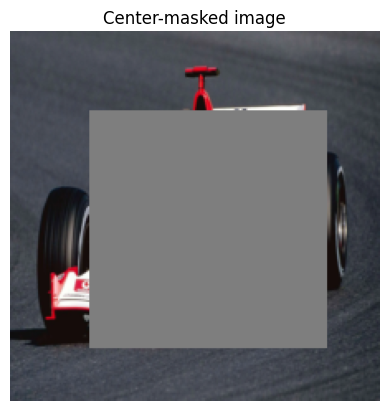

In [13]:
inputs=processor(images=image,return_tensors="pt").to(device)
pixel_values=inputs["pixel_values"].clone()
patch_size=16
grid_size=14
num_to_mask=int(0.5*196)
center=grid_size//2
offset=int((num_to_mask**0.5)//2)
chosen=[]
for r in range(center-offset,center+offset+1):
    for c in range(center-offset,center+offset+1):
        chosen.append(r*grid_size+c)
for idx in chosen:
    row=(idx//grid_size)*patch_size
    col=(idx%grid_size)*patch_size
    pixel_values[0,:,row:row+patch_size,col:col+patch_size]=0

img_view=pixel_values[0].cpu().permute(1,2,0).numpy()
img_view=(img_view-img_view.min())/(img_view.max()-img_view.min())
plt.imshow(img_view)
plt.title("Center-masked image")
plt.axis("off")
plt.savefig("masked_center.png",bbox_inches="tight")
plt.show()

Image was not central so could be the reason

In [14]:
from transformers import ViTModel

feature_vit=ViTModel.from_pretrained("google/vit-base-patch16-224").to(device)
feature_vit.eval()

def extract_features(images):
    inputs=processor(images=images,return_tensors="pt").to(device)
    with torch.no_grad():
        outputs=feature_vit(**inputs)
    hidden=outputs.last_hidden_state
    cls_features=hidden[:,0,:]
    mean_features=hidden[:,1:,:].mean(dim=1)
    return cls_features.cpu(),mean_features.cpu()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
from torchvision import datasets
cifar_train=datasets.CIFAR10(root="./data",train=True,download=True)
cifar_test=datasets.CIFAR10(root="./data",train=False,download=True)
def build_feature_set(dataset,num_images):
    cls_list=[]
    mean_list=[]
    label_list=[]
    for i in range(num_images):
        pil_image,label=dataset[i]
        cls_feat,mean_feat=extract_features(pil_image)
        cls_list.append(cls_feat)
        mean_list.append(mean_feat)
        label_list.append(label)
    cls_features=torch.cat(cls_list).numpy()
    mean_features=torch.cat(mean_list).numpy()
    labels=label_list
    return cls_features,mean_features,labels
train_cls,train_mean,train_labels=build_feature_set(cifar_train,1000)
test_cls,test_mean,test_labels=build_feature_set(cifar_test,300)

100%|██████████| 170M/170M [26:07<00:00, 109kB/s]


In [16]:
from sklearn.linear_model import LogisticRegression

cls_probe=LogisticRegression(max_iter=1000)
cls_probe.fit(train_cls,train_labels)
cls_accuracy=cls_probe.score(test_cls,test_labels)
mean_probe=LogisticRegression(max_iter=1000)
mean_probe.fit(train_mean,train_labels)
mean_accuracy=mean_probe.score(test_mean,test_labels)

print("CLS token probe accuracy:",cls_accuracy)
print("Mean-pool probe accuracy:",mean_accuracy)

CLS token probe accuracy: 0.96
Mean-pool probe accuracy: 0.95
